# Karar Laboratuvarı 02 — Bilgi Kümesini Yeni Öncü Verilerle Genişletmek

**Ortak yazarlar:** Pusula (karar mantığı ve anlatı) · Rota (çalıştırılabilir analiz, montaj ve QA)  
**Sabitler:** Target = `noter_devir_otomobil_adet`; sınıflar = up/stable/down; haftalık güncellenen aylık nowcast  
**Durum:** Arama şartnamesi; bu notebook veri çekmez, feature üretmez ve model fit etmez  
**Test:** Kilitli kalır

Temel soru şudur: **Mevcut Model 09 feature setinin erişemediği, M−2 anında gerçekten yayımlanmış ve devir yönüne nedensel/operasyonel mekanizmayla bağlanan bir öncü bilgi ailesi var mı?**

## Okuma hedefleri

1. “Daha fazla feature” ile “yeni bilgi” arasındaki farkı kurmak.
2. Mevcut on özelliğin kapsadığı sinyal ailelerini denetlemek.
3. Veri kaynağı indirmeden önce as-of uygunluk ve yayın gecikmesi kapısını tanımlamak.
4. Yeni veri turunun başarı standardını Model 11 ile aynı ölçekte önceden sabitlemek.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

def repo_kokunu_bul():
    baslangic = Path.cwd().resolve()
    for aday in [baslangic, *baslangic.parents]:
        if (aday / "README.md").exists() and (aday / "data").exists():
            return aday
    raise FileNotFoundError("Repo kökü bulunamadı. Notebook'u repo içinde çalıştırın.")

ROOT = repo_kokunu_bul()
MODEL_DIR = ROOT / "data" / "processed" / "model"

def json_oku(dosya_adi, fallback):
    yol = MODEL_DIR / dosya_adi
    if yol.exists():
        return json.loads(yol.read_text(encoding="utf-8")), f"canlı dosya: {yol.relative_to(ROOT)}"
    return fallback, f"raporda sabitlenmiş fallback: {dosya_adi}"

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_colwidth", 100)
print("Repo:", ROOT)

Repo: C:\Users\YOGA\Desktop\araç piyasasında yön analizi için kullanılan yöntemler - Kopya - Kopya


In [2]:
M09_FALLBACK = {"featurelar": [
    "ay_sin","ay_cos","is_gunu_ilerleme_orani",
    "usdtry_orta_ilk_son_degisim_pct","eurtry_orta_ilk_son_degisim_pct",
    "otv_event_gunu_mu_cari_ay_sayisi","tufe_aylik_degisim_lag2ay",
    "tasit_kredisi_faiz_lag2ay","hedef_m2_m3_degisim_pct","hedef_m12_m13_degisim_pct"
]}
M11_FALLBACK = {"bolum4_oracle_bilgi_tavani":{"oracle_b":{
    "lojistik_l2_c01":{"tavan_gozlenen":0.2147571548,"tavan_null95":0.4450343896},
    "lojistik_l2_c1":{"tavan_gozlenen":0.1689784848,"tavan_null95":0.4683733695},
    "random_forest_sigin":{"tavan_gozlenen":0.9168817091,"tavan_null95":0.9155435039},
    "hist_gradient_sigin":{"tavan_gozlenen":1.0,"tavan_null95":1.0}
}}, "test":"ACILMADI_KILITLI"}
m09, kaynak09 = json_oku("model_09_dusuk_kapasiteli_nowcast_validation.json", M09_FALLBACK)
m11, kaynak11 = json_oku("model_11_hedef_teshis_ozet.json", M11_FALLBACK)
print(kaynak09)
print(kaynak11)

canlı dosya: data\processed\model\model_09_dusuk_kapasiteli_nowcast_validation.json
canlı dosya: data\processed\model\model_11_hedef_teshis_ozet.json


## Neden algoritma değil bilgi ekseni?

Model 11’in oracle deneyi, mevcut feature temsiline dürüst bir out-of-fold modelden daha büyük avantaj verdi. Buna rağmen gözlenen tavan permütasyon null’ını ön-kayıtlı 0.15 marjla aşamadı. Bu sonuç “Random Forest yerine başka algoritma seçelim” hipotezini desteklemez.

Buna karşılık Model 11, **hiç toplanmamış öncü sinyallerin** işe yaramadığını söylemez. Seçenek 2’nin bilimsel gerekçesi budur: model ailesini değil, bilgi kümesini değiştirmek.

In [3]:
def kategori(feature):
    if feature in {"ay_sin","ay_cos","is_gunu_ilerleme_orani"}:
        return "takvim / ay-içi ilerleme"
    if "usdtry" in feature or "eurtry" in feature:
        return "kur"
    if "otv" in feature:
        return "vergi olayı"
    if "tufe" in feature or "faiz" in feature:
        return "gecikmeli makro / finansman"
    if "hedef_" in feature:
        return "hedefin kendi geçmişi"
    return "diğer"

feature_haritasi = pd.DataFrame({"feature": m09["featurelar"]})
feature_haritasi["bilgi_ailesi"] = feature_haritasi["feature"].map(kategori)
feature_haritasi.groupby("bilgi_ailesi", as_index=False).agg(
    feature_sayisi=("feature","size"),
    featurelar=("feature", lambda x: ", ".join(x))
)

,bilgi_ailesi,feature_sayisi,featurelar
0,gecikmeli makro / finansman,2,"tufe_aylik_degisim_lag2ay, tasit_kredisi_faiz_lag2ay"
1,hedefin kendi geçmişi,2,"hedef_m2_m3_degisim_pct, hedef_m12_m13_degisim_pct"
2,kur,2,"usdtry_orta_ilk_son_degisim_pct, eurtry_orta_ilk_son_degisim_pct"
3,takvim / ay-içi ilerleme,3,"ay_sin, ay_cos, is_gunu_ilerleme_orani"
4,vergi olayı,1,otv_event_gunu_mu_cari_ay_sayisi


## Boşluk analizi

Yeni aday şu soruya “evet” diyebilmelidir:

> Aday, tahmin anında erişilebilir olup mevcut on feature’ın açıklamadığı bir talep, arz, finansman erişimi veya işlem niyeti durumuna mı erişiyor?

Aynı kur serisini başka frekansta vermek, hedef lagına yeni dönüşüm uygulamak veya ay bilgisini farklı kodlamak otomatik olarak “yeni bilgi” değildir. Bunlar mevcut temsildeki sinyalin başka biçimleri olabilir ve Model 11’in null tavanını tekrar üretme riski taşır.

In [4]:
kapsam = pd.DataFrame([
    ["Takvim ve ay-içi ilerleme", True, "ay_sin/cos + iş günü ilerlemesi"],
    ["Kur hareketi", True, "USDTRY ve EURTRY ay-içi değişim"],
    ["Gecikmeli enflasyon/faiz", True, "TÜFE ve taşıt kredisi faizi, lag2"],
    ["Vergi olayı", True, "ÖTV olay günü sayısı"],
    ["Hedef hafızası/mevsimsellik", True, "M−2/M−3 ve M−12/M−13 türevleri"],
    ["Gerçek zamanlı işlem niyeti", False, "mevcut feature setinde yok"],
    ["İlan arzı, stok ve ilan yaşı", False, "mevcut feature setinde yok"],
    ["Finansmana fiili erişim/onay", False, "faiz oranı erişim değildir"],
    ["Fiyat pazarlığı ve satışa dönüşüm", False, "mevcut feature setinde yok"],
], columns=["bilgi_ailesi","mevcut_temsilde_var","kanıt/not"])
kapsam

,bilgi_ailesi,mevcut_temsilde_var,kanıt/not
0,Takvim ve ay-içi ilerleme,True,ay_sin/cos + iş günü ilerlemesi
1,Kur hareketi,True,USDTRY ve EURTRY ay-içi değişim
2,Gecikmeli enflasyon/faiz,True,"TÜFE ve taşıt kredisi faizi, lag2"
3,Vergi olayı,True,ÖTV olay günü sayısı
4,Hedef hafızası/mevsimsellik,True,M−2/M−3 ve M−12/M−13 türevleri
5,Gerçek zamanlı işlem niyeti,False,mevcut feature setinde yok
6,"İlan arzı, stok ve ilan yaşı",False,mevcut feature setinde yok
7,Finansmana fiili erişim/onay,False,faiz oranı erişim değildir
8,Fiyat pazarlığı ve satışa dönüşüm,False,mevcut feature setinde yok


## Aday veri aileleri: hipotezdir, kaynak doğrulaması değildir

Aşağıdaki aileler yalnız boşluk üretmek için listelenir; veri erişimi, tarihsel kapsamı ve yayın gecikmesi bu notebookta doğrulanmamıştır.

- Arama/görüntüleme/favori/iletişim gibi **işlem niyeti** sinyalleri
- Aktif ilan sayısı, yeni ilan, ilandan kalkma, ilan yaşı ve satıcı stokları
- Kredi başvurusu/onayı veya fiili kullandırım gibi **finansmana erişim** sinyalleri
- İlan fiyatı–gerçekleşen satış farkına yaklaşan pazarlık/dönüşüm sinyalleri
- Bayi/ihale/ekspertiz kanalındaki yüksek frekanslı talep ve arz göstergeleri

Her aday için mekanizma, as-of erişilebilirlik ve mevcut temsilden fark açıkça yazılmadan veri çekimine başlanmamalıdır.

In [5]:
aday_karti = pd.DataFrame([{
    "aday_adi": "",
    "kaynak_sahibi": "",
    "ham_frekans": "",
    "ilk_tarih": "",
    "yayin_gecikmesi_gun": pd.NA,
    "M_eksi_2_aninda_erisim": pd.NA,
    "revizyon_politikasi": "",
    "kapatilan_bilgi_boslugu": "",
    "mekanizma_bir_cumle": "",
    "mevcut_featuredan_neden_farkli": "",
    "hukuki/erişim_riski": "",
}])
aday_karti

,aday_adi,kaynak_sahibi,ham_frekans,ilk_tarih,yayin_gecikmesi_gun,M_eksi_2_aninda_erisim,revizyon_politikasi,kapatilan_bilgi_boslugu,mekanizma_bir_cumle,mevcut_featuredan_neden_farkli,hukuki/erişim_riski
0,,,,,<NA>,<NA>,,,,,


## Yeni veri turu için ön-kayıt standardı

Bir adayın model hattına girmesi için sıralı kapılar:

1. **As-of kapısı:** Her observation’ın ilk yayın zamanı bilinmeli; M−1 ve M ayı bilgisi sızıntı olarak maskelenmeli.
2. **Kapsam kapısı:** Rolling-origin için yeterli tarihsel pencere olmalı; sonradan geriye doldurulan serilerin vintaj riski açıklanmalı.
3. **Yenilik kapısı:** Aday, kapsam matrisindeki gerçek bir boşluğa düşmeli.
4. **Tavan kapısı:** Model 11 oracle protokolü yeni bilgiyle yeniden uygulandığında gözlenen tavan, kendi permütasyon null95’ını en az **0.15** aşmalı.
5. **Yalnız bundan sonra performans:** Tavan kapısı geçmeden rolling-origin model kıyasına başlanmamalı.

Bu notebook yalnız kapıları yazar; hiçbirini geçmiş ilan etmez.

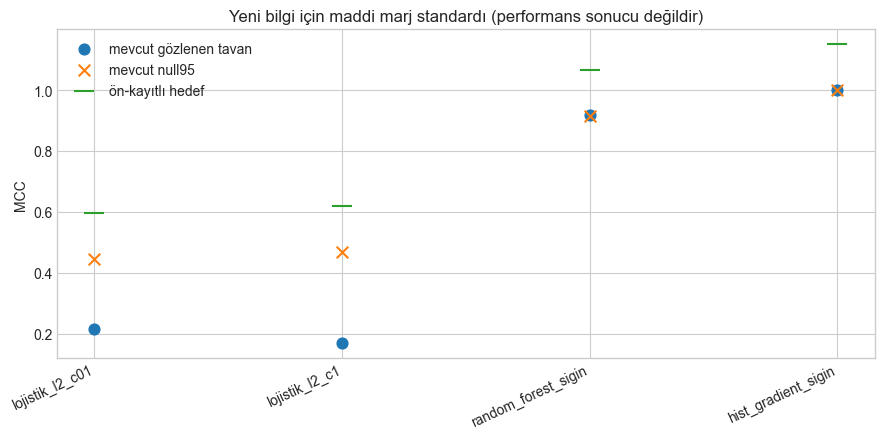

,aday,mevcut_gözlenen,mevcut_null95,yeni_bilgi_hedefi_null95_artı_0_15
0,lojistik_l2_c01,0.214757,0.445034,0.595034
1,lojistik_l2_c1,0.168978,0.468373,0.618373
2,random_forest_sigin,0.916882,0.915544,1.065544
3,hist_gradient_sigin,1.000000,1.000000,1.150000


In [6]:
oracle = m11["bolum4_oracle_bilgi_tavani"]["oracle_b"]
oracle_df = pd.DataFrame([
    [ad, v["tavan_gozlenen"], v["tavan_null95"], v["tavan_null95"] + 0.15]
    for ad, v in oracle.items()
], columns=["aday","mevcut_gözlenen","mevcut_null95","yeni_bilgi_hedefi_null95_artı_0_15"])

x = range(len(oracle_df))
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.scatter(x, oracle_df["mevcut_gözlenen"], label="mevcut gözlenen tavan", s=60)
ax.scatter(x, oracle_df["mevcut_null95"], label="mevcut null95", marker="x", s=70)
ax.scatter(x, oracle_df["yeni_bilgi_hedefi_null95_artı_0_15"], label="ön-kayıtlı hedef", marker="_", s=200)
ax.set_xticks(list(x), oracle_df["aday"], rotation=25, ha="right")
ax.set_ylabel("MCC")
ax.set_title("Yeni bilgi için maddi marj standardı (performans sonucu değildir)")
ax.legend()
plt.tight_layout()
plt.show()
oracle_df

## Yanlış yorumlama kontrol listesi

- Oracle RF≈0.917 ve HGB=1.000 skorları gerçek beceri değildir; null skorları da aynı düzeydedir.
- Makro değişkenin ekonomik önemi, tahmin anında yeni bilgi taşıdığını tek başına göstermez.
- Geriye dönük doldurulmuş seri, o tarihte biliniyormuş gibi kullanılamaz; vintaj/as-of kaydı gerekir.
- Feature sayısını artırmak başarı kriteri değildir. Yeni bilgi ailesi, tavan kapısını geçmedikçe ilerleme sayılmaz.
- Bu listedeki veri aileleri erişilebilir veya ücretsiz ilan edilmemiştir.

## Karar kapısı

Seçenek 2, ancak **en az bir aday kartı** şu koşullarla eksiksiz doldurulursa uygulama ön-kaydına taşınabilir:

- M−2 anında erişim kanıtlı,
- tarihsel kapsam rolling-origin için yeterli,
- mevcut feature haritasındaki bir boşluğu kapatıyor,
- mekanizma ve yayın gecikmesi yazılı,
- oracle null95+0.15 eşiği önceden kabul edilmiş.

Kart yoksa veya aday yalnız mevcut sinyalin başka dönüşümüyse bu seçenek “başlatıldı” sayılmaz. Çıktı şu anda bir veri seti değil, **arama ve kabul şartnamesidir**.

## Ortak karar puanlama şeması

Üç seçenek aynı dört eksende 0–3 puanlanır. Bu tablo otomatik kazanan üretmez; puan ile gerekçenin birlikte kaydedilmesini zorunlu kılar.

| Eksen | 0 puan | 3 puan |
|---|---|---|
| Kanıt gücü | Spekülasyon | Model 09→10→11 zincirinin doğrudan sonucu |
| Maliyet / tersinirlik | K değişikliği, yeni ön-kayıt ve/veya yeni kaynak | Yalnız dokümantasyon; karar geri alınabilir |
| Belirsizlik azaltımı | Yeni ve büyük bir açık soru seti doğurur | Mevcut açık soruyu kapatır |
| Kapsam sadakati | Sabit hedef/sınıf/ufuk kararını değiştirir | Sabitlerin hiçbirine dokunmaz |

Puanlar tek başına karar değildir. Her puanın yanına kanıt referansı yazılmadan toplam alınmamalıdır.

In [7]:
puanlama_sablonu = pd.DataFrame(
    [
        ["1 — hedefi kapat", pd.NA, pd.NA, pd.NA, pd.NA, ""],
        ["2 — bilgi kümesini genişlet", pd.NA, pd.NA, pd.NA, pd.NA, ""],
        ["3 — ufuk/toplulaştırma/sınıf değiştir", pd.NA, pd.NA, pd.NA, pd.NA, ""],
    ],
    columns=["seçenek", "kanıt_gücü_0_3", "maliyet_tersinirlik_0_3",
             "belirsizlik_azaltımı_0_3", "kapsam_sadakati_0_3", "kanıt_gerekçesi"],
)
puanlama_sablonu

,seçenek,kanıt_gücü_0_3,maliyet_tersinirlik_0_3,belirsizlik_azaltımı_0_3,kapsam_sadakati_0_3,kanıt_gerekçesi
0,1 — hedefi kapat,<NA>,<NA>,<NA>,<NA>,
1,2 — bilgi kümesini genişlet,<NA>,<NA>,<NA>,<NA>,
2,3 — ufuk/toplulaştırma/sınıf değiştir,<NA>,<NA>,<NA>,<NA>,


## Sonuç

Model 11 mevcut temsili elemiştir; henüz gözlenmemiş bilgi ailelerini değil. Bu notebook, hedefi ve üç sınıfı koruyan tek geliştirme yolunun nasıl disiplinli biçimde sınanacağını tanımlar. Veri edinimi ve model koşusu ayrı bir aşamadır.